<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/CNN/CNN_fer2013_revisit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image classification Project:
Dataset : Fer2023plus, link:
Project goal: Train the model to identify the image classification based on sentiment ( sad, happy, anger, etc)
Libraries used : pandas, numpy, matplotlib, os, cv2
Model : CNN , sigmoid

In [20]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# -----------------------------
# PATHS
# -----------------------------
raw_train_path = "/content/drive/MyDrive/AI-python/lecture39/image_folder/train_data"
clean_path = "/content/drive/MyDrive/AI-python/lecture39/cleaned_train"
processed_path = "/content/drive/MyDrive/AI-python/lecture39/processed_train"

IMG_SIZE = 64  # ResNet50 input size
blur_threshold = 100
min_size = 40

# Create folders for cleaned/processed images
for emotion in os.listdir(raw_train_path):
    emotion_path = os.path.join(raw_train_path, emotion)
    if not os.path.isdir(emotion_path):
        continue
    os.makedirs(os.path.join(clean_path, emotion), exist_ok=True)
    os.makedirs(os.path.join(processed_path, emotion), exist_ok=True)

print("Folder structure created!")


Folder structure created!
Folder structure created!


Initialize counters and create list and pre processing of the images and image vectorization

In [21]:
final_images = []
labels = []
processed_filenames = []
label_map = {}

corrupt_count = 0
blurred_count = 0
small_removed_count = 0
kept_count = 0

for idx, emotion in enumerate(sorted(os.listdir(raw_train_path))):
    emotion_path = os.path.join(raw_train_path, emotion)
    if not os.path.isdir(emotion_path):
        continue

    label_map[idx] = emotion

    for file in os.listdir(emotion_path):
        input_path = os.path.join(emotion_path, file)

        # 1. Check corrupt
        try:
            img_pil = Image.open(input_path)
            img_pil.verify()
        except:
            corrupt_count += 1
            continue

        # 2. Read image
        img = cv2.imread(input_path)
        if img is None:
            corrupt_count += 1
            continue

        h, w = img.shape[:2]

        # 3. Remove small images
        if h < min_size or w < min_size:
            small_removed_count += 1
            continue

        # 4. Remove blurry images
        gray_tmp = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_value = cv2.Laplacian(gray_tmp, cv2.CV_64F).var()
        if blur_value < blur_threshold:
            blurred_count += 1
            continue

        # 5. Save clean image
        cv2.imwrite(os.path.join(clean_path, emotion, file), img)
        kept_count += 1

        # 6. Preprocess for CNN
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        equalized = cv2.equalizeHist(gray)
        resized_img = cv2.resize(equalized, (IMG_SIZE, IMG_SIZE))

        # Convert grayscale to RGB
        rgb_img = np.stack([resized_img]*3, axis=-1)

        # Save processed
        cv2.imwrite(os.path.join(processed_path, emotion, file), cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

        # Append to arrays
        final_images.append(rgb_img)
        labels.append(idx)
        processed_filenames.append((idx, file))

# Convert to numpy arrays
X_train = np.array(final_images) / 255.0
y_train = to_categorical(np.array(labels), num_classes=len(label_map))

print(f"Images kept: {kept_count}, Corrupt: {corrupt_count}, Small removed: {small_removed_count}, Blurry removed: {blurred_count}")
print("Number of classes:", len(label_map))

Images kept: 800, Corrupt: 0, Small removed: 0, Blurry removed: 0
Number of classes: 8


Sample image before and after processing

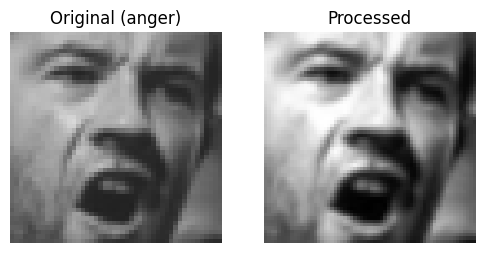

In [22]:
i = 0  # choose sample
label_idx, filename = processed_filenames[i]
emotion_label = label_map[label_idx]

raw_sample_path = os.path.join(raw_train_path, emotion_label, filename)
raw_sample = cv2.imread(raw_sample_path)
raw_sample = cv2.cvtColor(raw_sample, cv2.COLOR_BGR2RGB)
processed_sample = X_train[i]

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(raw_sample)
plt.title(f"Original ({emotion_label})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed_sample)
plt.title("Processed")
plt.axis("off")
plt.show()

In [23]:
print("\n================ SUMMARY ================")
print(f"Total images processed: {len(final_images)}")
print(f"Corrupted images removed: {corrupt_count}")
print(f"Small images removed: {small_removed_count}")
print(f"Blurry images removed: {blurred_count}")
print(f"Images kept: {kept_count}")
print("Number of classes:", len(label_map))
print("Label map:", label_map)
print("========================================\n")


================ SUMMARY ================
Total images processed: 800
Corrupted images removed: 0
Small images removed: 0
Blurry images removed: 0
Images kept: 800
Number of classes: 8
Label map: {0: 'anger', 1: 'contempt', 2: 'disgust', 3: 'fear', 4: 'happiness', 5: 'neutral', 6: 'sadness', 7: 'surprise'}



Cell 4 — Build ResNet50 Model with GlobalAveragePooling
1.   List item
2.   List item



In [25]:
num_classes = len(label_map)

# Input layer
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)

# Freeze base model initially
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Train model on full training set

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1  # optional, useful for monitoring
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 650ms/step - accuracy: 0.1389 - loss: 2.3059 - val_accuracy: 0.0000e+00 - val_loss: 2.0320
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 434ms/step - accuracy: 0.1389 - loss: 2.1158 - val_accuracy: 0.0000e+00 - val_loss: 2.4286
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 523ms/step - accuracy: 0.1514 - loss: 2.0535 - val_accuracy: 0.0000e+00 - val_loss: 2.7218
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 511ms/step - accuracy: 0.1403 - loss: 2.0319 - val_accuracy: 0.0000e+00 - val_loss: 2.9476
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 443ms/step - accuracy: 0.1639 - loss: 2.0227 - val_accuracy: 0.0000e+00 - val_loss: 3.1123
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 507ms/step - accuracy: 0.1722 - loss: 2.0185 - val_accuracy: 0.0000e+00 - val_loss: 3.2406
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 491ms/step - accuracy: 0.1417 - loss: 2.0162 - val_accuracy: 0.0000e+00 - val_loss: 3.2848
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 505ms/step - accuracy: 0.17

Fine-Tune Last Layers of ResNet50

In [29]:
# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.1444 - loss: 2.1739 - val_accuracy: 0.0000e+00 - val_loss: 3.5143
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.2861 - loss: 1.8821 - val_accuracy: 0.0000e+00 - val_loss: 3.5599
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.3917 - loss: 1.6849 - val_accuracy: 0.0000e+00 - val_loss: 3.5760
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.4750 - loss: 1.5679 - val_accuracy: 0.0000e+00 - val_loss: 3.6005
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5750 - loss: 1.4469 - val_accuracy: 0.0000e+00 - val_loss: 3.5836
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6264 - loss: 1.3626 - val_accuracy: 0.0000e+00 - val_loss: 3.4920
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6833 - loss: 1.2651 - val_accuracy: 0.0000e+00 - val_loss: 3.3923
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7375 - loss: 1.1809 - val_

Plot the graph for acuracy and loss

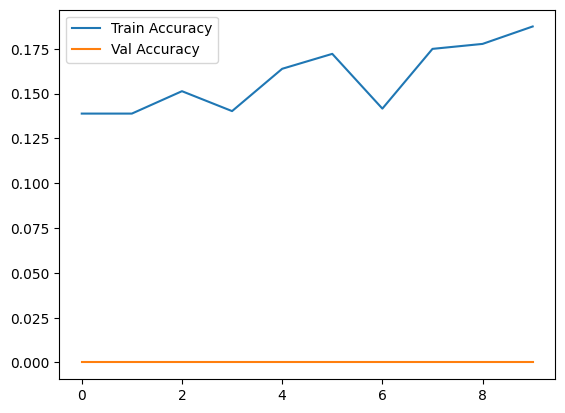

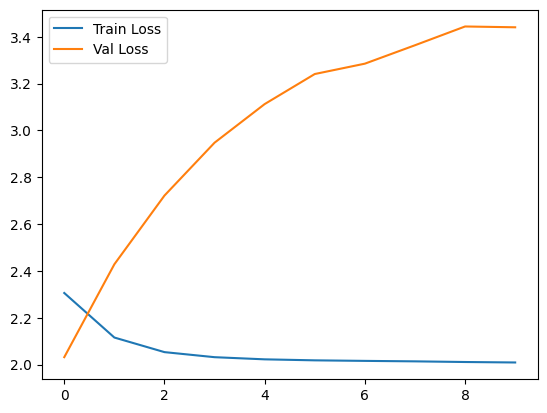

In [32]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Val Accuracy')
plt.legend(); plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Val Loss')
plt.legend(); plt.show()

Initial model accuracy

In [33]:
# Training metrics
train_acc = history.history['accuracy'][-1]           # last epoch training accuracy
val_acc = history.history['val_accuracy'][-1]        # last epoch validation accuracy

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Final Training Accuracy: 0.1875
Final Validation Accuracy: 0.0000


Fine tuning model accuracy

In [34]:
# After fine-tuning
train_acc = history_finetune.history['accuracy'][-1]
val_acc = history_finetune.history.get('val_accuracy', None)
print(f"Final Fine-Tuned Training Accuracy: {train_acc:.4f}")
if val_acc is not None:
    print(f"Final Fine-Tuned Validation Accuracy: {val_acc[-1]:.4f}")

Final Fine-Tuned Training Accuracy: 0.8069
Final Fine-Tuned Validation Accuracy: 0.0000


Testing a image from web

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import requests

url = "https://i.imgur.com/8Km9tLL.jpg"
headers = {'User-Agent': 'Mozilla/5.0'}
resp = requests.get(url, headers=headers, stream=True)
image = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [37]:
# Convert to grayscale for equalization, then back to RGB
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray)
resized_img = cv2.resize(equalized, (64, 64))
rgb_img = np.stack([resized_img]*3, axis=-1)  # 64x64x3

# Normalize
input_img = rgb_img / 255.0
input_img = np.expand_dims(input_img, axis=0)  # shape: (1,64,64,3)

In [38]:
# Predict using your trained model
prediction = model.predict(input_img)
predicted_class = np.argmax(prediction)

# Map to emotion
emotion_label = label_map[predicted_class]
print("Predicted Emotion:", emotion_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Emotion: neutral


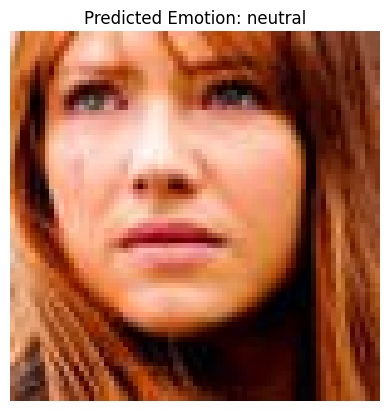

In [39]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted Emotion: {emotion_label}")
plt.axis("off")
plt.show()